In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from typing import List
import os
mpl.rcParams['pdf.fonttype'] = 42
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import scipy
import random
from matplotlib.pyplot import rc_context

In [2]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [3]:
def refresh_celltype(path, celltype_1, adata, celltype_2):
    adata_tmp = sc.read_h5ad(path)
    adata.obs[celltype_2] = adata.obs[celltype_2].astype('object')
    adata.obs.loc[adata_tmp.obs_names, celltype_2] = adata_tmp.obs[celltype_1]
    adata.obs[celltype_2] = adata.obs[celltype_2].astype('category')
    return adata

In [4]:
adata = sc.read_h5ad('./data/scRNA/RNA.merged.analysed.h5ad')

In [53]:
adata.obs['refined_celltype'] = adata.obs['celltype'].copy()

In [75]:
adata = refresh_celltype('./data/adata_NKT.h5ad', 'NKT_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_Myeloid.h5ad', 'Myeloid_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_B.h5ad', 'B_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_Epi.h5ad', 'Epi_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_Fibro.h5ad', 'Fibro_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_SMC.h5ad', 'SMC_celltype', adata, 'refined_celltype' )
adata = refresh_celltype('./data/adata_Endo.h5ad', 'Endo_celltype', adata, 'refined_celltype' )

In [11]:
 order = ['CCR7+ CD8 Tncm', 'PRF1+ CD8 CTL', 'GZMK+ CD8 Teff', 'NR4A2+ CD8 Tem',
       'PDCD1+ CD8 Tex', 'TCF7+ CD4 Tncm', 'ANKRD36+ CD4 Tm', 'CXCR4+ CD4 Trm',
       'CXCL13+ CD4 Tfh', 'Treg', 'gdT', 'IGHM+ Naive B', 'CD27+ Memory B',
       'IgG PC', 'IgA PC', 'FCGR3A+ NK', 'XCL1+ NK', 'Neutrophil',
       'CD14+ Mono', 'CD16+ Mono', 'IL1B+ Macro', 'C1QA+ Macro', 'cDC1',
       'cDC2', 'mregDC', 'pDC', 'Mast cell', 'Platelet', 'CFD+ Fibro',
       'CRABP1+ Fibro', 'Myofibroblast', 'Pericyte', 'SMC', 'Myoblast',
       'SBSN+ Epi', 'COL17A1+ Epi', 'GPX2+ Epi', 'MKI67+ Epi', 'SG Epithelium',
       'ACKR1+ Endo', 'SEMA3G+ Endo', 'CA4+ Endo', 'INSR+ Endo', 'LEC',
       'others']

In [81]:
adata.obs['refined_celltype'] = adata.obs.refined_celltype.cat.reorder_categories(order)

In [ ]:
adata.uns['refined_celltype_colors'] = ['#00F5FF', '#98F5FF', '#00CED1', '#7AC5CD', '#E0FFFF', '#0000EE',
       '#00008B', '#1E90FF', '#6495ED', '#8470FF', '#87CEFA', '#B0C4DE',
       '#C6E2FF', '#333333', '#2F4F4F', '#00688B', '#5F9EA0', '#FFDAB9',
       '#CD6600', '#8B4500', '#E9967A', '#FF8C00', '#F08080', '#CDAF95',
       '#FF7256', '#BC8F8F', '#FFD700', '#CDAD00', '#8B008B', '#BF3EFF',
       '#AB82FF', '#5D478B', '#FF00FF', '#A020F0', '#8B0000', '#FF1493',
       '#FF69B4', '#CD5C5C', '#FFB6C1', '#556B2F', '#BDB76B', '#CAFF70',
       '#C1FFC1', '#20B2AA', '#A9A9A9']

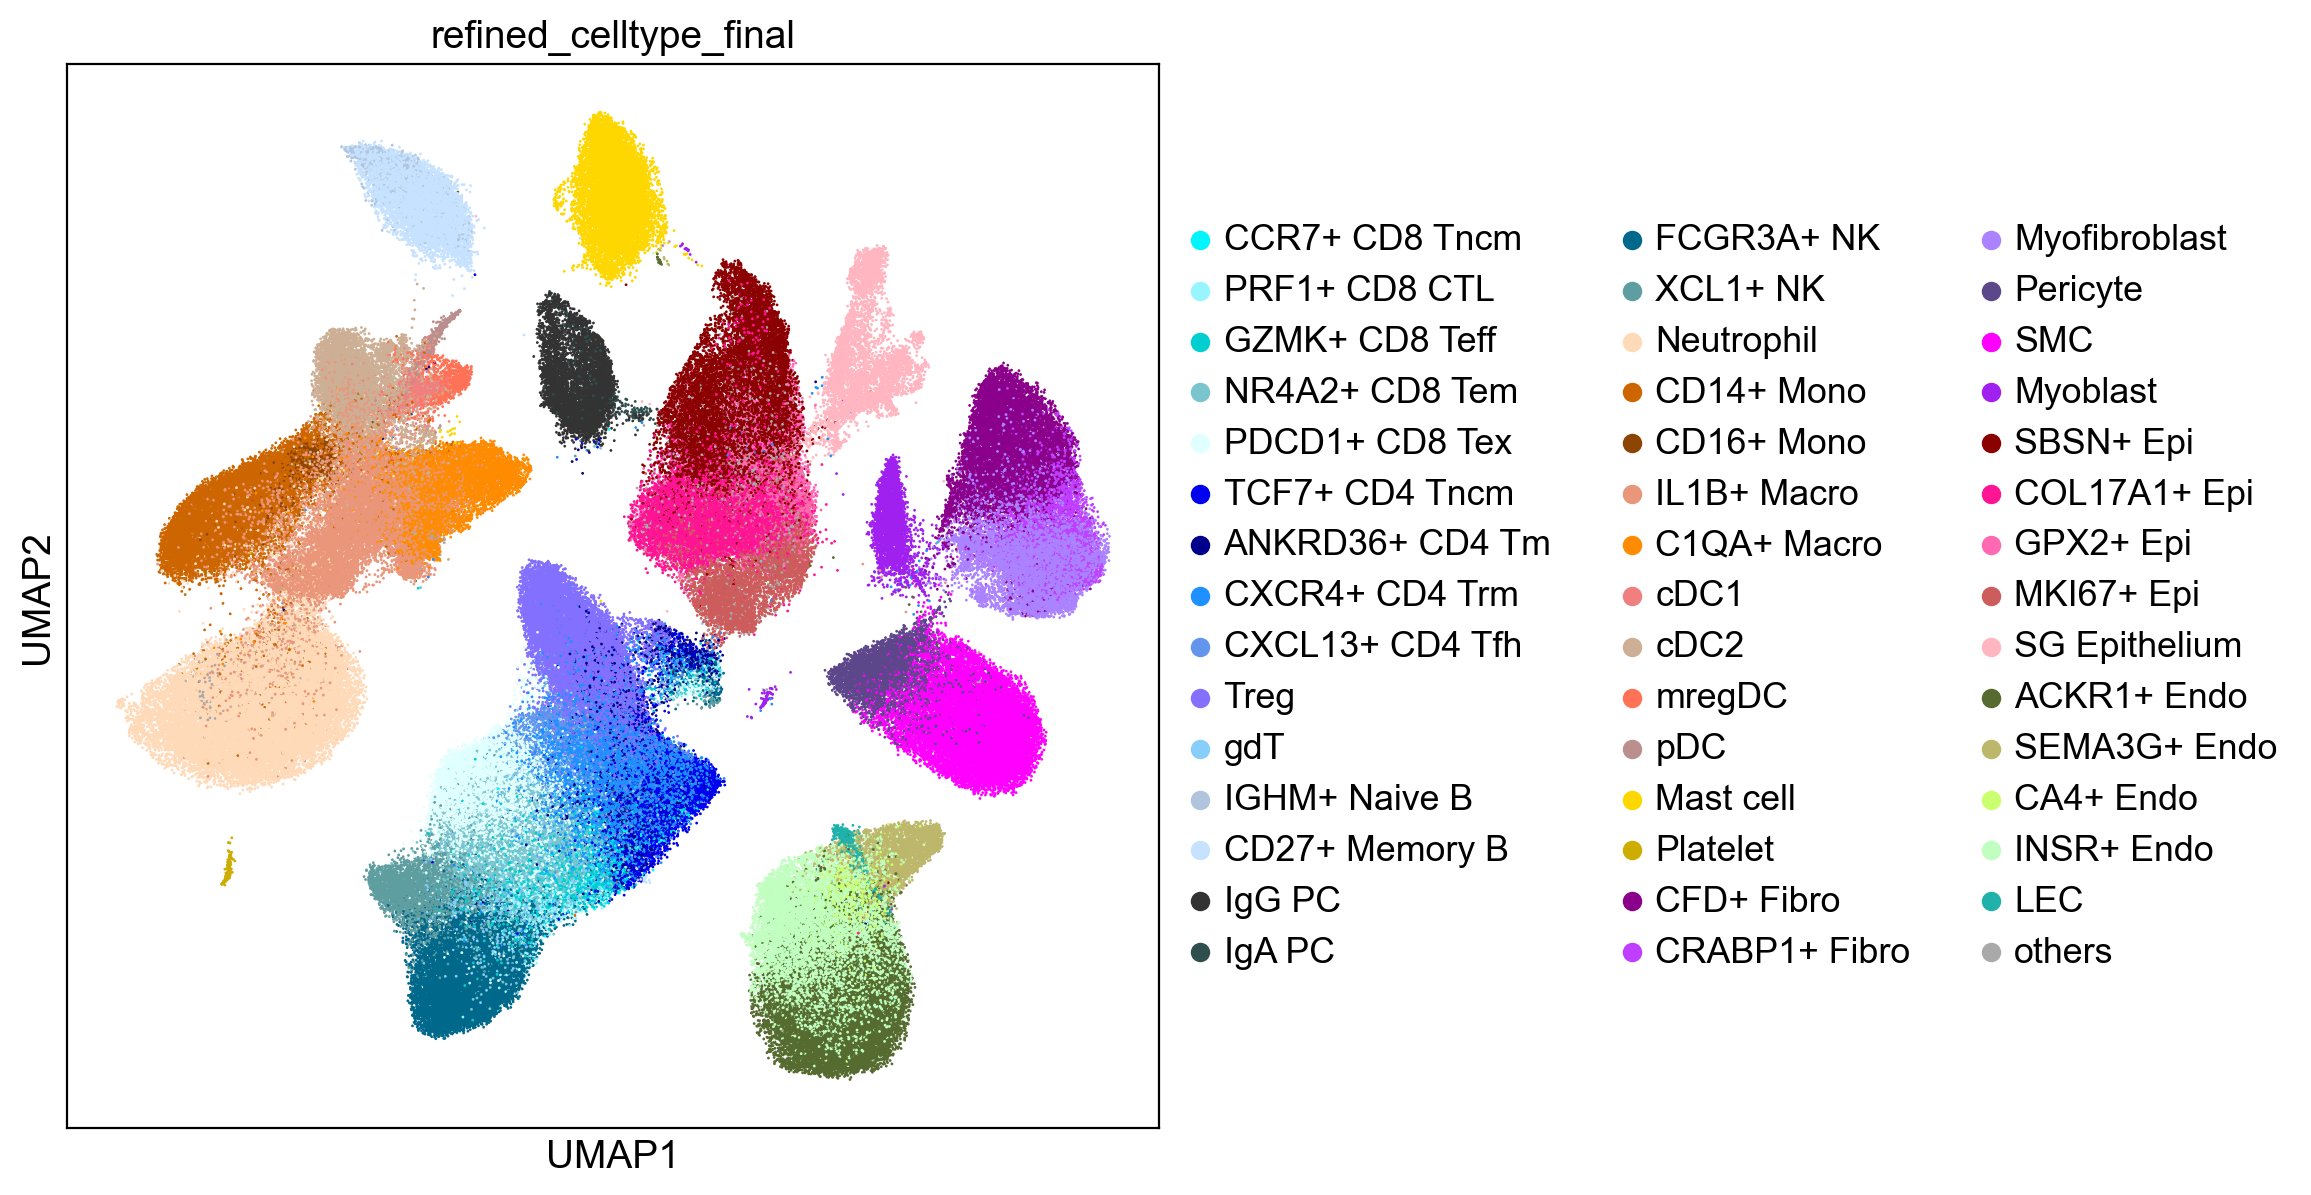

In [6]:
with rc_context({'figure.figsize':(7,7)}):
    sc.pl.umap(adata, color=['refined_celltype'], size=4)

In [31]:
adata.write_h5ad('./data/scRNA/RNA.merged.analysed.h5ad')